# Joint Modeling of Latent Cognitive States and Decision Processes: HMM with DDM Emissions

This tutorial demonstrates how to build a **Hidden Markov Model (HMM)** whose emission distribution is a **Drift Diffusion Model (DDM)**, using HSSM's low-level API.

**Motivation.** In many cognitive tasks, participants do not maintain the same internal state throughout an experiment. They may alternate between an *attentive* and a *distracted* state, or shift between *speed-emphasis* and *accuracy-emphasis* strategies. A regime-switching DDM captures this by letting one or more DDM parameters change according to a latent Markov chain.

**Model overview.**

- **Latent regimes:** $s_t \mid s_{t-1} \sim \text{Categorical}(P_{s_{t-1}, \cdot})$, where $P$ is a $K \times K$ transition matrix.
- **Emissions:** $(rt_t, \text{response}_t) \mid s_t = k \sim \text{DDM}(v_k, a, z, t)$. Here, drift rate $v$ switches across regimes while $a$, $z$, and $t$ are shared.
- **Inference:** The discrete regime sequence is marginalized out via the forward algorithm (in log-space), yielding a model with only continuous free parameters suitable for NUTS sampling.

The tutorial shows two emission backends that plug into the same HMM scaffold:

1. **Analytical DDM** -- HSSM's `DDM` distribution (PyTensor, Navarro & Fuss 2009).
2. **Approx differentiable DDM** -- HSSM's default LAN (ONNX) via `make_distribution_for_supported_model`.

Both are sampled with `nuts_sampler="numpyro"` (JAX backend).

## Colab Instructions

If you would like to run this tutorial on Google Colab, uncomment and run the installation cell below, then **restart your runtime**.

You may want to switch your runtime to GPU/TPU for faster sampling. Go to *Runtime* > *Change runtime type*.

In [1]:
# Uncomment below if running on Colab
# !pip install hssm

---
## Part 1: Setup

In [2]:
# --- Core scientific Python ---
import arviz as az  # Bayesian inference diagnostics and plotting
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm  # Probabilistic programming framework
import pytensor  # Symbolic tensor library (backend for PyMC)
import pytensor.tensor as pt
from scipy.special import logsumexp  # Numerically stable log-sum-exp

# --- HSSM ---
import hssm
from hssm.likelihoods import (  # Analytical DDM distribution and log-likelihood
    DDM,
    logp_ddm,
)

---
## Part 2: Simulate Regime-Switching DDM Data

We generate synthetic data from a 2-regime HMM-DDM where the drift rate $v$ switches between regimes while all other parameters are shared. This gives us ground-truth labels to evaluate regime recovery later.

In [3]:
def simulate_hmm_ddm_data(
    n_trials,
    regime_params,
    P,
    pi0,
    seed=42,
):
    """Simulate data from a regime-switching DDM.

    Parameters
    ----------
    n_trials : int
        Number of trials.
    regime_params : dict[int, dict]
        DDM parameters per regime, e.g. {0: {"v": 0.5, ...}, 1: {"v": -0.5, ...}}.
    P : np.ndarray
        (K, K) transition matrix.
    pi0 : np.ndarray
        (K,) initial regime distribution.
    seed : int
        Random seed.

    Returns
    -------
    data : np.ndarray
        (n_trials, 2) array of [rt, response].
    regimes : np.ndarray
        (n_trials,) ground-truth regime labels.
    """
    rng = np.random.default_rng(seed)
    K = len(regime_params)

    # Step 1: Generate the latent regime sequence from the Markov chain.
    # The first regime is drawn from the initial distribution pi0,
    # and each subsequent regime is drawn from row P[s_{t-1}] of the transition matrix.
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for t in range(1, n_trials):
        regimes[t] = rng.choice(K, p=P[regimes[t - 1]])

    # Step 2: Simulate DDM data for each regime using HSSM's built-in simulator.
    # We batch-simulate all trials belonging to the same regime at once for efficiency.
    rts, responses = [], []
    for k in range(K):
        mask = regimes == k
        n_k = int(mask.sum())
        if n_k == 0:
            continue
        sims = hssm.simulate_data(
            model="ddm",
            theta=regime_params[k],  # DDM parameters for regime k
            size=n_k,
            random_state=seed + k,
            output_df=False,  # Return raw numpy array instead of DataFrame
        )
        rts.append(sims[:, 0])
        responses.append(sims[:, 1])

    # Step 3: Place simulated RTs and responses back into trial order.
    data = np.empty((n_trials, 2))
    for k in range(K):
        mask = regimes == k
        data[mask, 0] = rts[k]
        data[mask, 1] = responses[k]

    return data, regimes

In [4]:
# --- Ground-truth parameters for our simulation ---
N_TRIALS = 500  # Total number of trials
K = 2  # Number of hidden regimes

# DDM parameters per regime.
# Both regimes share the same boundary (a), starting point (z), and
# non-decision time (t).
# Only drift rate (v) differs: regime 0 has high drift (attentive),
# regime 1 has low drift (distracted).
TRUE_PARAMS = {
    0: {"v": 1.5, "a": 0.8, "z": 0.5, "t": 0.3},  # attentive: fast, accurate
    1: {"v": 0.2, "a": 0.8, "z": 0.5, "t": 0.3},  # distracted: slow, noisy
}

# Transition matrix: high diagonal = regimes are "sticky" (participants tend to stay
# in the same state). P[i, j] = probability of transitioning from regime i to regime j.
TRUE_P = np.array(
    [
        [0.95, 0.05],  # From attentive: 95% stay, 5% switch to distracted
        [0.10, 0.90],  # From distracted: 10% switch to attentive, 90% stay
    ]
)

# Initial regime distribution: 80% chance of starting in the attentive regime
TRUE_PI0 = np.array([0.8, 0.2])

# Generate the synthetic dataset
data, true_regimes = simulate_hmm_ddm_data(
    N_TRIALS,
    TRUE_PARAMS,
    TRUE_P,
    TRUE_PI0,
    seed=42,
)
print(f"Data shape: {data.shape}")
print(f"Regime counts: {np.bincount(true_regimes)}")
mean_rts = [f"{data[true_regimes == k, 0].mean():.3f}" for k in range(K)]
print(f"Mean RT by regime: {mean_rts}")

Data shape: (500, 2)
Regime counts: [328 172]
Mean RT by regime: ['0.811', '0.939']


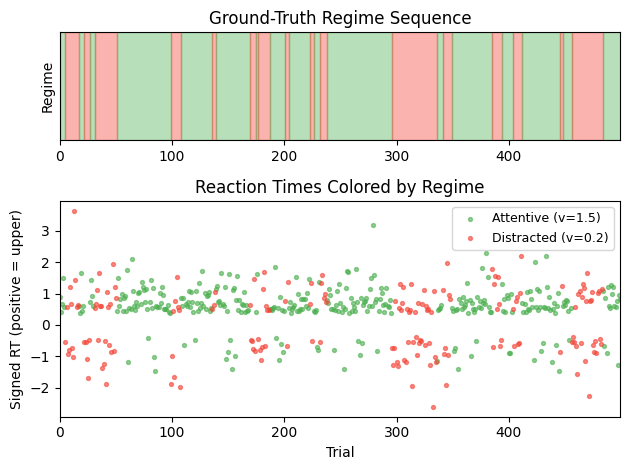

In [5]:
fig, axes = plt.subplots(2, 1, gridspec_kw={"height_ratios": [1, 2]})

# --- Top panel: color-coded regime sequence ---
# Each contiguous block of trials in the same regime gets a colored background band.
ax = axes[0]
regime_colors = {0: "#4CAF50", 1: "#F44336"}  # green = attentive, red = distracted
t_axis = np.arange(N_TRIALS)
start = 0
for t in range(1, N_TRIALS):
    if true_regimes[t] != true_regimes[t - 1] or t == N_TRIALS - 1:
        end = t if t < N_TRIALS - 1 else N_TRIALS
        ax.axvspan(start, end, alpha=0.4, color=regime_colors[true_regimes[start]])
        start = t
ax.set_xlim(0, N_TRIALS - 1)
ax.set_ylabel("Regime")
ax.set_yticks([])
ax.set_title("Ground-Truth Regime Sequence")

# --- Bottom panel: signed RT scatter plot ---
# "Signed RT" = RT * response, so upper-boundary responses are positive and
# lower-boundary responses are negative. This makes it easy to see both RT
# magnitude and choice direction in one plot.
ax = axes[1]
for k, label in enumerate(["Attentive (v=1.5)", "Distracted (v=0.2)"]):
    mask = true_regimes == k
    ax.scatter(
        t_axis[mask],
        data[mask, 0] * data[mask, 1],
        s=8,
        alpha=0.6,
        color=regime_colors[k],
        label=label,
    )
ax.set_xlabel("Trial")
ax.set_ylabel("Signed RT (positive = upper)")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim(0, N_TRIALS - 1)
ax.set_title("Reaction Times Colored by Regime")

fig.tight_layout()
plt.show()

---
## Part 3: Analytical HMM-DDM Model

We build a PyMC model that combines:

- A **Dirichlet prior** on each row of the transition matrix $P$ (with a "sticky" concentration favouring self-transitions),
- **Regime-specific drift rates** $v_0, v_1$ with a soft ordering constraint ($v_0 > v_1$) to prevent label switching,
- **Shared priors** for $a$, $z$, $t$,
- **DDM emission log-likelihoods** per regime via `pm.logp(DDM.dist(...), data)`, and
- The **forward algorithm** via `pytensor.scan`, contributed as a `pm.Potential`.

### How the HMM-DDM Likelihood Works

The likelihood of an **HMM-DDM** is calculated by integrating the continuous DDM densities into a discrete Hidden Markov Model framework using the **Forward Algorithm**.

1. **Local DDM Densities**: For every trial $t$, we calculate the likelihood of the observed response time and choice under each possible hidden state $k$.
2. **State Filtering**: We use a "forward pass" to track the probability of being in state $k$ at time $t$, given all previous observations.
3. **Recursive Update**: This forward probability is updated trial-by-trial by multiplying the previous trial's beliefs by the **transition matrix $P$** and the current trial's **DDM density**.
4. **Total Likelihood**: By summing these probabilities at the final trial $N$, we obtain the marginal likelihood of the entire dataset across all possible state sequences.

In [6]:
def build_hmm_ddm_analytical(data, K=2, sticky_diag=20.0, sticky_offdiag=2.0):
    """Build an HMM-DDM model with analytical DDM emissions.

    The discrete regime chain is marginalized via the forward algorithm,
    leaving only continuous parameters for NUTS.

    Parameters
    ----------
    data : np.ndarray
        (N, 2) array of [rt, response].
    K : int
        Number of regimes.
    sticky_diag / sticky_offdiag : float
        Dirichlet concentration for the transition matrix rows.

    Returns
    -------
    pm.Model
    """
    # Build the Dirichlet concentration matrix for the "sticky" prior.
    # High diagonal values (sticky_diag >> sticky_offdiag) encode our belief
    # that regime switches are rare -- i.e., the transition matrix P should
    # have large diagonal entries. This is a common prior for cognitive data.
    sticky_alpha = np.full((K, K), sticky_offdiag)
    np.fill_diagonal(sticky_alpha, sticky_diag)

    with pm.Model() as model:
        # =====================================================================
        # 1. TRANSITION MATRIX
        # Each row of P is drawn from a Dirichlet distribution.
        # P[i, j] = probability of switching from regime i to regime j.
        # We work in log-space throughout for numerical stability.
        # =====================================================================
        P = pm.Dirichlet("P", a=sticky_alpha, shape=(K, K))
        log_P = pt.log(P)
        log_pi0 = pt.log(pt.ones(K) / K)  # Uniform initial regime distribution

        # =====================================================================
        # 2. DDM PARAMETERS
        # v (drift rate) gets a separate value per regime, while a (boundary),
        # z (starting point), and t (non-decision time) are shared.
        # =====================================================================
        v = pm.Normal("v", mu=0.0, sigma=3.0, shape=(K,))  # One drift per regime
        a = pm.HalfNormal("a", sigma=2.0)  # Boundary separation (shared)
        z = pm.Beta("z", alpha=10, beta=10)  # Starting point bias (shared)
        t = pm.HalfNormal("t", sigma=0.5)  # Non-decision time (shared)

        # Soft ordering constraint to prevent label switching:
        # Without this, the sampler could freely swap regime 0 and 1 labels,
        # creating a bimodal posterior. We enforce v[0] > v[1] by assigning
        # -inf log-probability when violated.
        pm.Potential("v_order", pt.switch(v[0] > v[1], 0.0, -1e10))

        # =====================================================================
        # 3. EMISSION LOG-LIKELIHOODS
        # For each regime k, compute log p(data | DDM(v_k, a, z, t)).
        # This gives us an (N, K) matrix: the likelihood of every trial
        # under each possible regime.
        # =====================================================================
        data_obs = pt.as_tensor_variable(data.astype("float32"), name="data_obs")

        log_lik_components = []
        for k in range(K):
            # Create a DDM distribution with regime-specific drift rate
            dist_k = DDM.dist(v=v[k], a=a, z=z, t=t)
            # Evaluate its log-likelihood for ALL trials at once
            log_lik_k = pm.logp(dist_k, data_obs)
            log_lik_components.append(log_lik_k)
        log_lik = pt.stack(log_lik_components, axis=1)  # Shape: (N, K)

        # =====================================================================
        # 4. FORWARD ALGORITHM (in log-space)
        # This is the key step that marginalizes out the discrete regime sequence.
        #
        # We define "forward variables":
        #   log_alpha_t(k) = log p(observations_1..t, s_t = k | params)
        #
        # The recursion is:
        #   log_alpha_t(k) = log[ sum_j exp(log_alpha_{t-1}(j) + log P[j,k]) ]
        #                    + log p(y_t | s_t=k)
        #
        # In words: the probability of being in regime k at trial t equals
        # the sum over all regimes j at trial t-1 of:
        #   (probability of being in j) * (transition prob j->k) * (emission prob at t)
        #
        # pytensor.scan efficiently unrolls this recursion across all trials.
        # =====================================================================
        log_alpha_init = log_pi0 + log_lik[0]  # Initialize with prior * first emission

        def forward_step(log_lik_t, log_alpha_prev, log_P_):
            # log_alpha_prev[:, None] + log_P_ broadcasts to (K, K):
            #   entry [j, k] = log_alpha_{t-1}(j) + log P[j, k]
            # logsumexp over axis=0 marginalizes out the previous regime j,
            # then we add the current emission log-likelihood.
            return pt.logsumexp(log_alpha_prev[:, None] + log_P_, axis=0) + log_lik_t

        log_alphas, _ = pytensor.scan(
            fn=forward_step,
            sequences=[log_lik[1:]],  # Iterate over trials 1..N-1
            outputs_info=[log_alpha_init],  # Start from trial 0
            non_sequences=[log_P],  # Transition matrix is constant
        )

        # The marginal log-likelihood of the full sequence is obtained by
        # summing over regimes at the final time step:
        #   log p(y_1..N | params) = logsumexp_k( log_alpha_N(k) )
        # We add this as a Potential (unnormalized log-probability term) to the model.
        pm.Potential("hmm_loglik", pt.logsumexp(log_alphas[-1]))

    return model

/var/folders/lm/vzzhdjjd7l95rmw96f4cc7200000gq/T/ipykernel_29396/2524707417.py:101: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  log_alphas, _ = pytensor.scan(


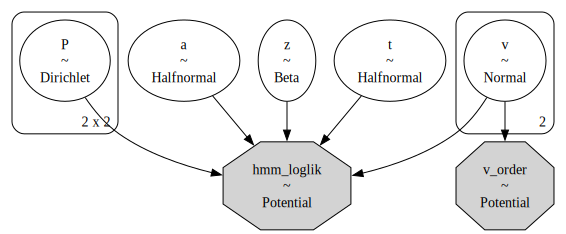

In [7]:
model_analytical = build_hmm_ddm_analytical(data, K=K)
pm.model_to_graphviz(model_analytical)

---
## Part 4: NUTS Sampling (Analytical)

Since `logp_ddm` is pure PyTensor, the entire model graph (including `pytensor.scan`) compiles to JAX automatically. We can therefore use the NumPyro NUTS sampler for efficient gradient-based inference.

In [8]:
# Sample the analytical HMM-DDM model using NUTS via NumPyro (JAX backend).
# - draws: number of posterior samples per chain (after tuning)
# - tune: number of warmup/adaptation steps (discarded)
# - target_accept: higher values = smaller step sizes = fewer divergences but slower
# - nuts_sampler="numpyro": use JAX-compiled NUTS for speed (vs. default PyMC sampler)
with model_analytical:
    idata_analytical = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        nuts_sampler="numpyro",
        random_seed=42,
    )

NUTS[numpyro]: [P, v, a, z, t]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/2000 [00:00<?, ?it/s]

warmup:   5%|▌         | 100/2000 [00:02<00:47, 40.03it/s, 15 steps of size 1.72e-02. acc. prob=0.87]

warmup:  10%|█         | 200/2000 [00:03<00:23, 75.36it/s, 7 steps of size 5.20e-01. acc. prob=0.88] 

...

sample:  95%|█████████▌| 1900/2000 [00:09<00:00, 213.58it/s, 15 steps of size 2.75e-01. acc. prob=0.96]

sample: 100%|██████████| 2000/2000 [00:09<00:00, 215.37it/s, 7 steps of size 2.75e-01. acc. prob=0.96] 

sample: 100%|██████████| 2000/2000 [00:09<00:00, 203.35it/s, 7 steps of size 2.75e-01. acc. prob=0.96]

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


### Diagnostics and Posterior Summary

In [9]:
az.summary(idata_analytical, var_names=["v", "a", "z", "t", "P"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v[0],1.17,0.18,0.92,1.5,942,953,1.00,0.0059,0.0099
v[1],-0,0.215,-0.35,0.32,1186,1171,1.00,0.0063,0.0049
a,0.804,0.0226,0.77,0.84,1245,1239,1.00,0.00064,0.00048
z,0.528,0.0174,0.5,0.55,1078,1107,1.00,0.00053,0.00037
t,0.3113,0.0081,0.3,0.32,1161,1138,1.00,0.00024,0.00017
"P[0, 0]",0.919,0.035,0.86,0.97,1090,995,1.00,0.0011,0.00093
"P[0, 1]",0.081,0.035,0.032,0.14,1090,995,1.00,0.0011,0.00093
"P[1, 0]",0.127,0.052,0.055,0.22,1102,861,1.00,0.0015,0.0012
"P[1, 1]",0.873,0.052,0.78,0.94,1102,861,1.00,0.0015,0.0012


In [10]:
print("True values for reference:")
print(f"  v = [{TRUE_PARAMS[0]['v']}, {TRUE_PARAMS[1]['v']}]")
print(f"  a = {TRUE_PARAMS[0]['a']}")
print(f"  z = {TRUE_PARAMS[0]['z']}")
print(f"  t = {TRUE_PARAMS[0]['t']}")
print(f"  P = {TRUE_P.tolist()}")

True values for reference:
  v = [1.5, 0.2]
  a = 0.8
  z = 0.5
  t = 0.3
  P = [[0.95, 0.05], [0.1, 0.9]]


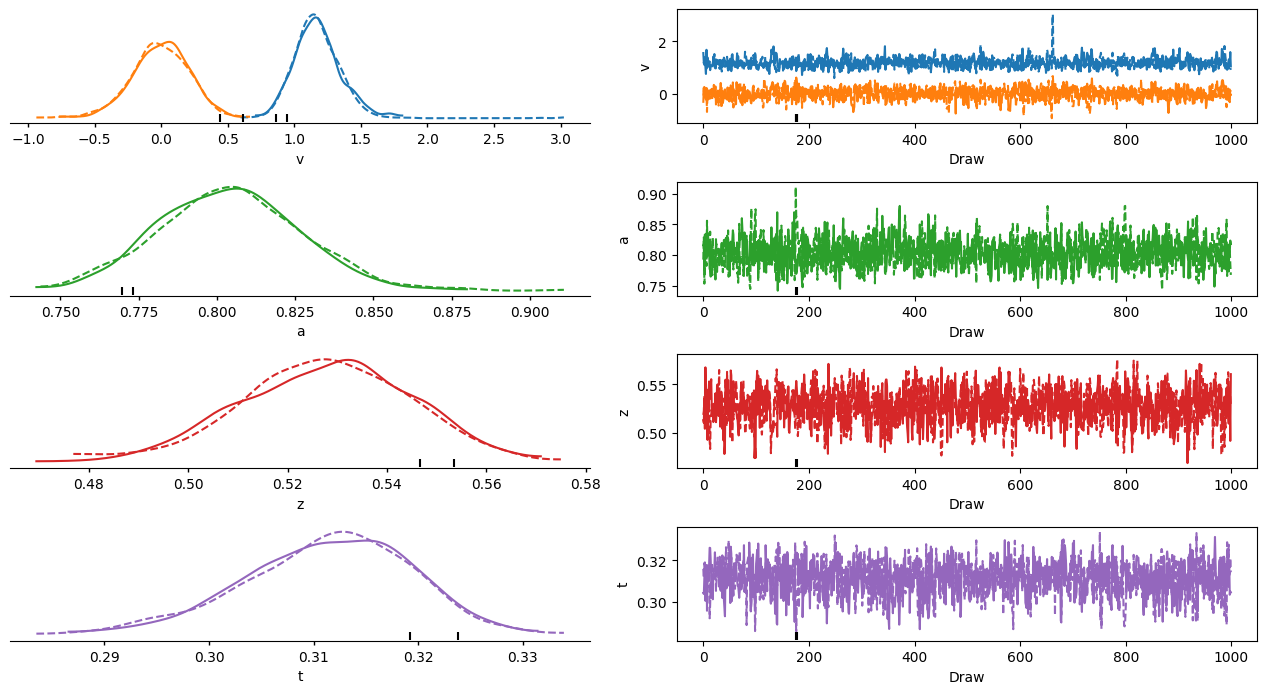

In [11]:
az.plot_trace_dist(idata_analytical, var_names=["v", "a", "z", "t"])
plt.tight_layout()
plt.show()

### Posterior Pair Plot (Analytical)

Pair plots help reveal correlations and trade-offs between DDM parameters across regimes.

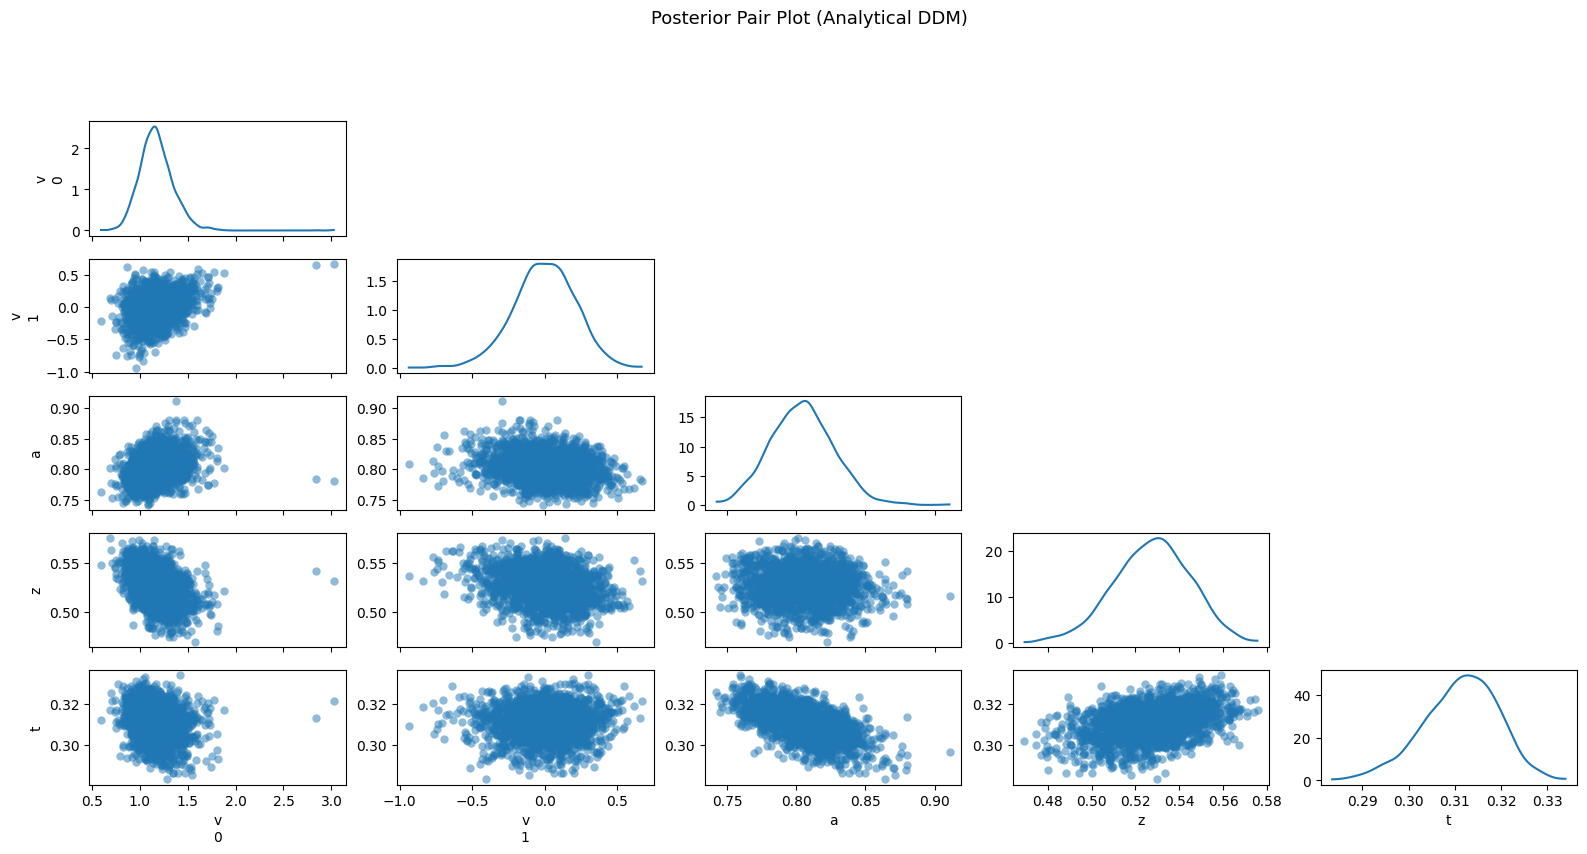

In [12]:
az.plot_pair(
    idata_analytical,
    var_names=["v", "a", "z", "t"],
)
plt.suptitle("Posterior Pair Plot (Analytical DDM)", fontsize=13, y=1.01)
plt.show()

---
## Part 5: Regime Recovery via Forward-Filter Backward-Sample (FFBS)

### Why do we need a separate step?

During NUTS sampling (Part 4), we **marginalized out** the discrete regime sequence to obtain a model with only continuous parameters. This is necessary because NUTS (a gradient-based sampler) cannot handle discrete latent variables directly. The forward algorithm gave us the marginal likelihood $p(y_{1:N} \mid \theta, P)$ summed over *all possible* regime sequences -- but it did not tell us *which* regime was active on each trial.

To recover the regime assignments, we use **Forward-Filter Backward-Sample (FFBS)**, a two-pass algorithm that runs *post-hoc* for each posterior draw of the continuous parameters $(\theta, P)$:

### Forward filter (same recursion as before)

Compute the forward variables $\alpha_t(k) = p(y_{1:t},\, s_t = k \mid \theta, P)$ from trial 1 to $N$. At each trial $t$, $\alpha_t(k)$ tells us: *"given everything observed so far, how likely is it that we are in regime $k$?"* This is a **filtering** distribution -- it only uses past and present data.

### Backward sample (why we need it)

Filtering alone is not enough. If we simply assigned regimes by picking $\arg\max_k \alpha_t(k)$ at each trial independently, we would ignore the Markov structure: the regime at trial $t$ constrains what is likely at trial $t+1$.

The backward pass fixes this by sampling regimes **in reverse order**, from trial $N$ back to trial 1:

$$p(s_t = k \mid s_{t+1}, y_{1:N}) \propto \alpha_t(k) \cdot P_{k,\, s_{t+1}}$$

In words: the probability of being in regime $k$ at trial $t$ combines the forward evidence ($\alpha_t$) with the transition probability into the *already-sampled* regime at trial $t+1$. This produces regime sequences that are **jointly consistent** with both the data and the Markov dynamics.

By repeating FFBS across many posterior draws, we obtain a full posterior distribution over regime assignments that accounts for uncertainty in both the parameters and the regime sequence.

### Implementation

We compile `logp_ddm` into a fast NumPy-callable function for this step.

In [13]:
# Compile the PyTensor logp_ddm into a fast NumPy-callable function.
# During model fitting (Part 3-4), the DDM log-likelihood lived inside PyTensor's
# symbolic computation graph. For FFBS we need a plain NumPy function we can call
# in a Python loop, so we compile it with pytensor.function().

_data_var = pt.matrix("data")  # Symbolic placeholder for (N, 2) data
_v_var = pt.scalar("v")
_a_var = pt.scalar("a")
_z_var = pt.scalar("z")
_t_var = pt.scalar("t")

logp_ddm_compiled = pytensor.function(
    [_data_var, _v_var, _a_var, _z_var, _t_var],
    logp_ddm(_data_var, _v_var, _a_var, _z_var, _t_var),
    on_unused_input="ignore",
)
print("Compiled logp_ddm -> NumPy callable.")

Compiled logp_ddm -> NumPy callable.


In [14]:
def compute_ddm_emission_loglik(data, v_vec, a_val, z_val, t_val, K):
    """Compute (N, K) DDM emission log-likelihoods for all regimes.

    For each regime k, evaluates log p(data | DDM(v_k, a, z, t)) using the
    compiled analytical DDM likelihood function.
    """
    N = data.shape[0]
    log_lik = np.empty((N, K))
    for k in range(K):
        log_lik[:, k] = logp_ddm_compiled(
            data.astype(np.float32),
            np.float32(v_vec[k]),
            np.float32(a_val),
            np.float32(z_val),
            np.float32(t_val),
        )
    return log_lik


def ffbs_single_ddm(data, P_draw, v_draw, a_draw, z_draw, t_draw, rng):
    """Forward-filter backward-sample for one posterior draw.

    Given a single set of posterior parameters (v, a, z, t, P), this function:
    1. Computes DDM emission log-likelihoods for all trials under each regime.
    2. Runs a forward pass to get filtering distributions alpha_t(k).
    3. Runs a backward pass to sample a full regime sequence.

    Returns a (N,) array of sampled regime labels.
    """
    K = P_draw.shape[0]
    N = data.shape[0]

    # Step 1: Emission log-likelihoods -- shape (N, K)
    log_lik = compute_ddm_emission_loglik(data, v_draw, a_draw, z_draw, t_draw, K)
    log_P = np.log(P_draw + 1e-300)  # Add tiny constant to avoid log(0)
    pi0 = np.ones(K) / K  # Uniform initial regime distribution

    # ---- FORWARD PASS ----
    # Compute log_alpha[t, k] = log p(y_1..t, s_t = k | params)
    # This is the same recursion as in Part 3, but in NumPy instead of PyTensor.
    log_alpha = np.empty((N, K))
    log_alpha[0] = np.log(pi0 + 1e-300) + log_lik[0]
    for t_idx in range(1, N):
        for k in range(K):
            # Sum over previous regimes: sum_j alpha_{t-1}(j) * P(j -> k)
            log_alpha[t_idx, k] = (
                logsumexp(log_alpha[t_idx - 1] + log_P[:, k]) + log_lik[t_idx, k]
            )

    # ---- BACKWARD SAMPLE ----
    # Sample regimes in reverse order: t = N-1, N-2, ..., 0
    regimes = np.empty(N, dtype=int)

    # Last trial: sample from the normalized forward distribution
    # p(s_N = k | y_1..N) ∝ alpha_N(k)
    log_gamma = log_alpha[N - 1] - logsumexp(log_alpha[N - 1])
    regimes[N - 1] = rng.choice(K, p=np.exp(log_gamma))

    # Earlier trials: combine forward evidence with transition to
    # already-sampled next regime
    # p(s_t = k | s_{t+1}, y_1..N) ∝ alpha_t(k) * P(k -> s_{t+1})
    for t_idx in range(N - 2, -1, -1):
        log_gamma = log_alpha[t_idx] + log_P[:, regimes[t_idx + 1]]
        log_gamma -= logsumexp(log_gamma)  # Normalize to valid probabilities
        regimes[t_idx] = rng.choice(K, p=np.exp(log_gamma))

    return regimes

In [15]:
# --- Run FFBS across many posterior draws ---
# We randomly select 200 posterior draws (from all chains), run FFBS for each,
# and collect the resulting regime sequences. This gives us a posterior
# distribution over regime assignments at each trial.

n_ffbs_draws = 200
rng = np.random.default_rng(123)

# Extract posterior samples as numpy arrays
posterior = idata_analytical.posterior
v_samples = posterior["v"].values  # Shape: (chains, draws, K)
a_samples = posterior["a"].values  # Shape: (chains, draws)
z_samples = posterior["z"].values
t_samples = posterior["t"].values
P_samples = posterior["P"].values  # Shape: (chains, draws, K, K)

# Randomly select which (chain, draw) pairs to use
n_chains, n_draws = v_samples.shape[:2]
flat_indices = rng.choice(n_chains * n_draws, size=n_ffbs_draws, replace=False)

# Run FFBS for each selected posterior draw
regime_draws = np.empty((n_ffbs_draws, N_TRIALS), dtype=int)
for i, idx in enumerate(flat_indices):
    c, d = divmod(idx, n_draws)  # Convert flat index back to (chain, draw)
    regime_draws[i] = ffbs_single_ddm(
        data,
        P_draw=P_samples[c, d],
        v_draw=v_samples[c, d],
        a_draw=a_samples[c, d],
        z_draw=z_samples[c, d],
        t_draw=t_samples[c, d],
        rng=rng,
    )

# Compute posterior probability of regime 1 ("distracted") at each trial
# by averaging across all FFBS draws.
regime_probs = (regime_draws == 1).mean(axis=0)
print(f"FFBS complete: {n_ffbs_draws} regime sequences sampled.")

FFBS complete: 200 regime sequences sampled.


### Regime Recovery Visualization

We plot the posterior probability of being in regime 1 ("distracted") alongside the ground truth.

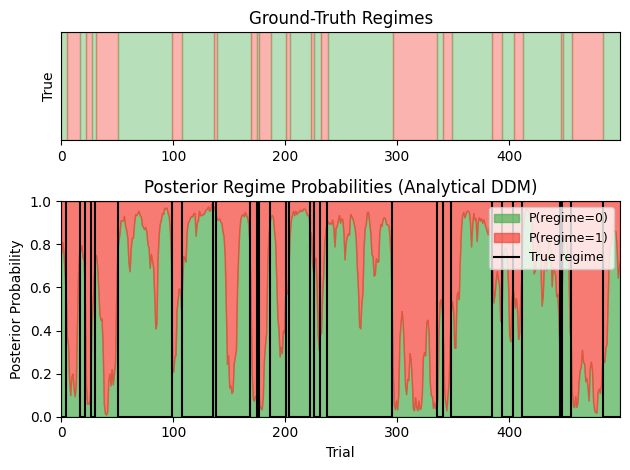

In [16]:
def plot_regime_recovery(regime_probs, true_regimes, title_suffix=""):
    """Stacked area plot of posterior regime probabilities vs ground truth.

    Top panel: ground-truth regime bands (green = attentive, red = distracted).
    Bottom panel: posterior probability of each regime as a stacked area chart,
    with the true regime boundary overlaid as a step function.
    """
    N = len(true_regimes)
    trials = np.arange(N)

    fig, axes = plt.subplots(2, 1, gridspec_kw={"height_ratios": [1, 2]})

    # --- Top panel: ground-truth regime bands ---
    ax = axes[0]
    start = 0
    for t_idx in range(1, N):
        if true_regimes[t_idx] != true_regimes[t_idx - 1] or t_idx == N - 1:
            end = t_idx if t_idx < N - 1 else N
            ax.axvspan(start, end, alpha=0.4, color=regime_colors[true_regimes[start]])
            start = t_idx
    ax.set_xlim(0, N - 1)
    ax.set_ylabel("True")
    ax.set_yticks([])
    ax.set_title("Ground-Truth Regimes")

    # --- Bottom panel: posterior regime probabilities ---
    # The stacked area shows how confident the model is about each regime.
    # Where the model is uncertain, both colors contribute roughly equally.
    ax = axes[1]
    p0 = 1 - regime_probs  # P(regime=0) = 1 - P(regime=1)
    ax.fill_between(trials, 0, p0, alpha=0.7, color="#4CAF50", label="P(regime=0)")
    ax.fill_between(trials, p0, 1, alpha=0.7, color="#F44336", label="P(regime=1)")
    ax.step(
        trials, true_regimes, where="mid", color="k", linewidth=1.5, label="True regime"
    )
    ax.set_xlabel("Trial")
    ax.set_ylabel("Posterior Probability")
    ax.set_xlim(0, N - 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(f"Posterior Regime Probabilities{title_suffix}")

    fig.tight_layout()
    plt.show()


plot_regime_recovery(regime_probs, true_regimes, title_suffix=" (Analytical DDM)")

---
## Part 6: Approx Differentiable HMM-DDM (LAN via ONNX)

This section demonstrates how to swap the emission likelihood with HSSM's **approximate differentiable** DDM. Under the hood, this uses a pre-trained Likelihood Approximation Network (LAN) stored as an ONNX model that ships with HSSM.

The HMM scaffold (priors, forward algorithm, `pm.Potential`) is *identical* -- only the emission distribution changes. This illustrates the modularity of the approach.

In [17]:
# Use HSSM's utility to create an approximate (LAN-based) DDM distribution class.
# This wraps a pre-trained neural network (stored as an ONNX model) that approximates
# the DDM log-likelihood. It accepts the same parameters as the analytical DDM
# but evaluates faster for complex models where no closed-form solution exists.
from hssm.distribution_utils import make_distribution_for_supported_model

DDMApprox = make_distribution_for_supported_model(
    model="ddm",
    loglik_kind="approx_differentiable",  # Use the LAN (neural network) approximation
    backend="pytensor",  # Ensure the output is a PyTensor-compatible distribution
)
print(f"Approx DDM distribution class: {DDMApprox}")
print(f"Parameters: {DDMApprox._params}")

Approx DDM distribution class: <class 'hssm.distribution_utils.dist.make_distribution.<locals>.HSSMDistribution'>
Parameters: ['v', 'a', 'z', 't']


In [18]:
def build_hmm_ddm_approx(data, K=2, sticky_diag=20.0, sticky_offdiag=2.0):
    """Build an HMM-DDM model with approx_differentiable (LAN) emissions.

    Same HMM scaffold as the analytical version, but using HSSM's
    pre-trained ONNX LAN for the DDM emission likelihood.

    The ONLY difference from build_hmm_ddm_analytical() is the distribution
    used for emission log-likelihoods: DDMApprox instead of DDM.
    Everything else -- priors, forward algorithm, Potential -- is identical.
    """
    # Sticky Dirichlet prior (same as analytical version)
    sticky_alpha = np.full((K, K), sticky_offdiag)
    np.fill_diagonal(sticky_alpha, sticky_diag)

    with pm.Model() as model:
        # --- Transition matrix (same as analytical) ---
        P = pm.Dirichlet("P", a=sticky_alpha, shape=(K, K))
        log_P = pt.log(P)
        log_pi0 = pt.log(pt.ones(K) / K)

        # --- DDM parameters (same priors as analytical) ---
        v = pm.Normal("v", mu=0.0, sigma=3.0, shape=(K,))
        a = pm.HalfNormal("a", sigma=2.0)
        z = pm.Beta("z", alpha=10, beta=10)
        t = pm.HalfNormal("t", sigma=0.5)

        # Label-switching prevention (same as analytical)
        pm.Potential("v_order", pt.switch(v[0] > v[1], 0.0, -1e10))

        # --- Emission log-likelihoods per regime (approx_differentiable) ---
        # This is the ONLY line that differs: DDMApprox instead of DDM.
        # The LAN approximation lets us use the same pattern for models
        # where no analytical likelihood exists (e.g., angle, levy, etc.).
        data_obs = pt.as_tensor_variable(data.astype("float32"), name="data_obs")

        log_lik_components = []
        for k in range(K):
            dist_k = DDMApprox.dist(v=v[k], a=a, z=z, t=t)  # LAN instead of analytical
            log_lik_k = pm.logp(dist_k, data_obs)
            log_lik_components.append(log_lik_k)
        log_lik = pt.stack(log_lik_components, axis=1)  # (N, K)

        # --- Forward algorithm (identical to analytical) ---
        log_alpha_init = log_pi0 + log_lik[0]

        def forward_step(log_lik_t, log_alpha_prev, log_P_):
            return pt.logsumexp(log_alpha_prev[:, None] + log_P_, axis=0) + log_lik_t

        log_alphas, _ = pytensor.scan(
            fn=forward_step,
            sequences=[log_lik[1:]],
            outputs_info=[log_alpha_init],
            non_sequences=[log_P],
        )

        pm.Potential("hmm_loglik", pt.logsumexp(log_alphas[-1]))

    return model

/var/folders/lm/vzzhdjjd7l95rmw96f4cc7200000gq/T/ipykernel_29396/1911333652.py:53: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  log_alphas, _ = pytensor.scan(


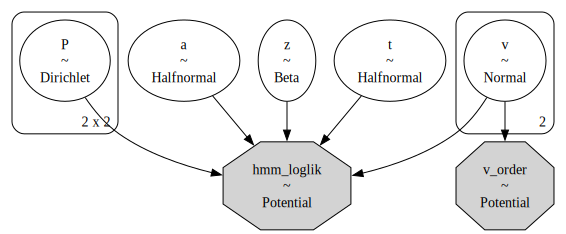

In [19]:
model_approx = build_hmm_ddm_approx(data, K=K)
pm.model_to_graphviz(model_approx)

### Sampling the Approx Differentiable Model

In [20]:
# Sample the LAN-based HMM-DDM model -- same sampling settings as analytical.
# This lets us directly compare posteriors between the two emission backends.
with model_approx:
    idata_approx = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        nuts_sampler="numpyro",
        random_seed=42,
    )

NUTS[numpyro]: [P, v, a, z, t]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/2000 [00:00<?, ?it/s]

warmup:   5%|▌         | 100/2000 [00:10<03:14,  9.75it/s, 31 steps of size 2.24e-02. acc. prob=0.87]

warmup:  10%|█         | 200/2000 [00:13<01:48, 16.60it/s, 15 steps of size 5.14e-01. acc. prob=0.88]

...

sample:  95%|█████████▌| 1900/2000 [00:48<00:02, 45.01it/s, 7 steps of size 3.26e-01. acc. prob=0.94] 

sample: 100%|██████████| 2000/2000 [00:50<00:00, 45.39it/s, 7 steps of size 3.26e-01. acc. prob=0.94]

sample: 100%|██████████| 2000/2000 [00:50<00:00, 39.35it/s, 7 steps of size 3.26e-01. acc. prob=0.94]


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


In [21]:
az.summary(idata_approx, var_names=["v", "a", "z", "t", "P"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v[0],1.18,0.2,0.89,1.5,764,888,1.00,0.0074,0.0056
v[1],0.04,0.207,-0.32,0.35,1125,1022,1.00,0.0062,0.0047
a,0.78,0.023,0.75,0.82,1254,1285,1.00,0.00065,0.00053
z,0.53,0.0188,0.5,0.56,1030,1086,1.00,0.00059,0.0004
t,0.3152,0.0091,0.3,0.33,1158,1130,1.00,0.00027,0.0002
"P[0, 0]",0.917,0.04,0.85,0.97,1005,1174,1.00,0.0012,0.0011
"P[0, 1]",0.083,0.04,0.03,0.15,1005,1174,1.00,0.0012,0.0011
"P[1, 0]",0.121,0.051,0.05,0.21,1033,923,1.00,0.0015,0.0012
"P[1, 1]",0.879,0.051,0.79,0.95,1033,923,1.00,0.0015,0.0012


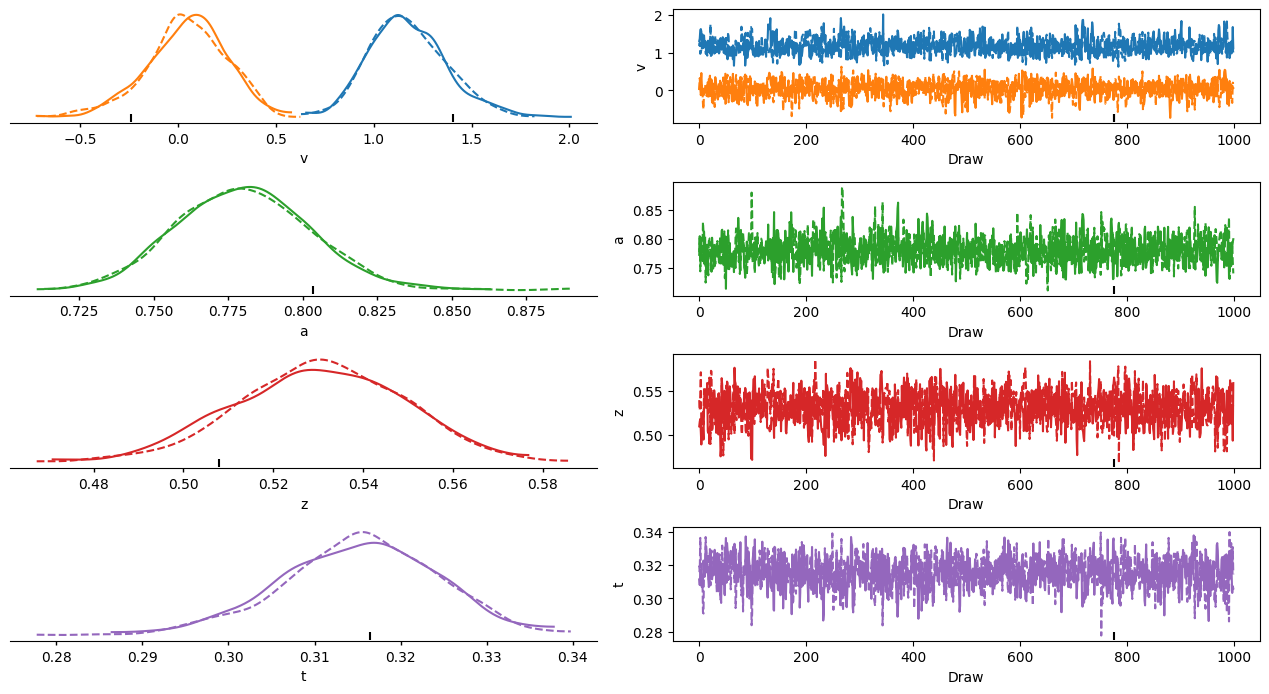

In [22]:
az.plot_trace_dist(idata_approx, var_names=["v", "a", "z", "t"])
plt.tight_layout()
plt.show()

### Posterior Pair Plot (LAN)

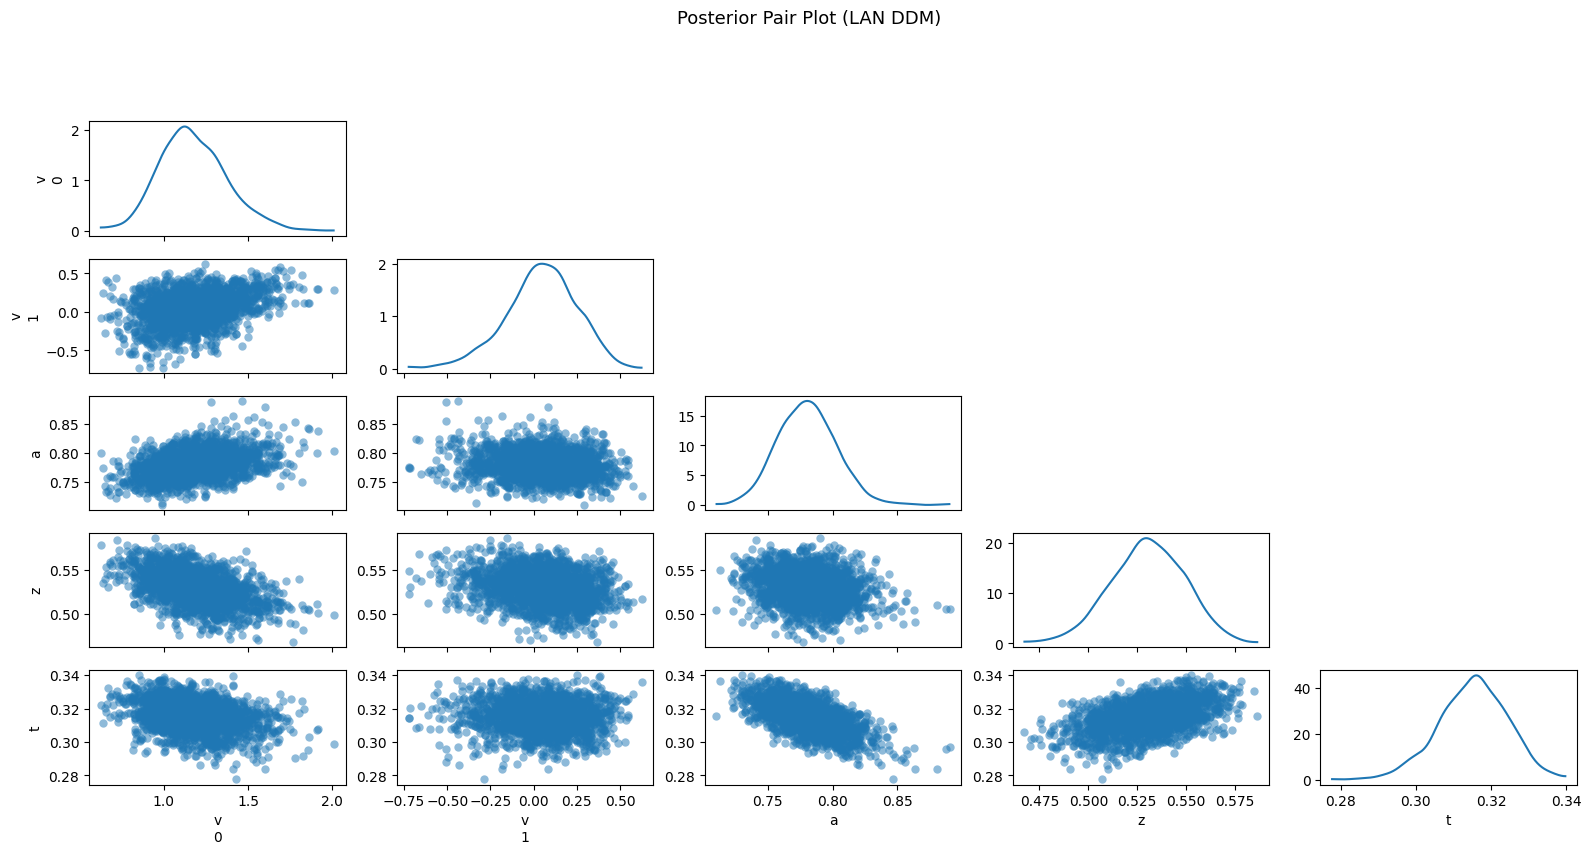

In [23]:
az.plot_pair(
    idata_approx,
    var_names=["v", "a", "z", "t"],
)
plt.suptitle("Posterior Pair Plot (LAN DDM)", fontsize=13, y=1.01)
plt.show()

### Regime Recovery (LAN)

We run the same FFBS procedure using the LAN model's posterior draws. Since FFBS only needs a fast NumPy log-likelihood evaluator, we reuse the compiled analytical `logp_ddm` for regime recovery regardless of which likelihood was used during sampling.

In [24]:
# --- Run FFBS for the LAN model's posterior draws ---
# Same procedure as for the analytical model. We reuse the compiled analytical
# logp_ddm for regime recovery -- this is valid because FFBS only needs a
# point-evaluation of the DDM density, and the analytical version is exact.
rng_approx = np.random.default_rng(456)

# Extract LAN posterior samples
posterior_approx = idata_approx.posterior
v_samples_ap = posterior_approx["v"].values
a_samples_ap = posterior_approx["a"].values
z_samples_ap = posterior_approx["z"].values
t_samples_ap = posterior_approx["t"].values
P_samples_ap = posterior_approx["P"].values

# Randomly select posterior draws and run FFBS
n_chains_ap, n_draws_ap = v_samples_ap.shape[:2]
flat_indices_ap = rng_approx.choice(
    n_chains_ap * n_draws_ap, size=n_ffbs_draws, replace=False
)

regime_draws_approx = np.empty((n_ffbs_draws, N_TRIALS), dtype=int)
for i, idx in enumerate(flat_indices_ap):
    c, d = divmod(idx, n_draws_ap)
    regime_draws_approx[i] = ffbs_single_ddm(
        data,
        P_draw=P_samples_ap[c, d],
        v_draw=v_samples_ap[c, d],
        a_draw=a_samples_ap[c, d],
        z_draw=z_samples_ap[c, d],
        t_draw=t_samples_ap[c, d],
        rng=rng_approx,
    )

regime_probs_approx = (regime_draws_approx == 1).mean(axis=0)
print(f"FFBS (LAN) complete: {n_ffbs_draws} regime sequences sampled.")

FFBS (LAN) complete: 200 regime sequences sampled.


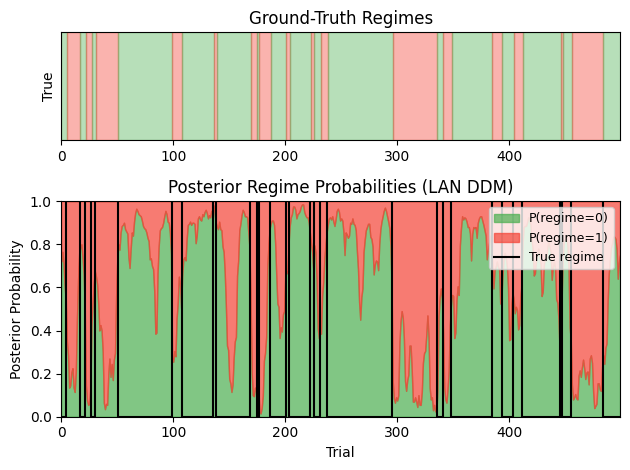

In [25]:
plot_regime_recovery(regime_probs_approx, true_regimes, title_suffix=" (LAN DDM)")

---
## Part 7: Comparing Analytical vs. Approx Differentiable Posteriors

Let's overlay the posterior distributions from both backends to assess how closely the LAN approximation tracks the analytical solution.

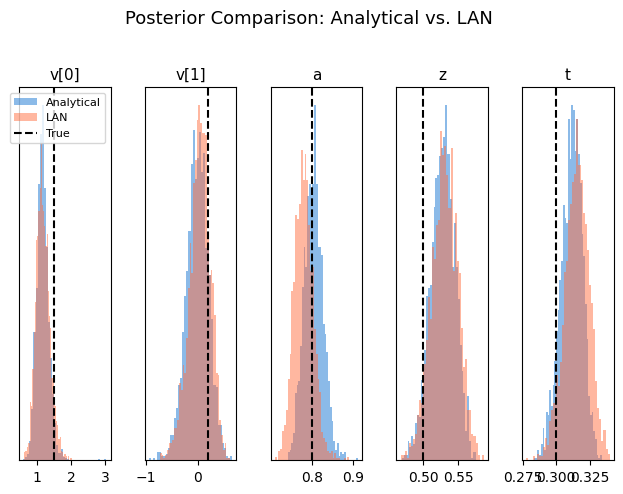

In [26]:
# --- Compare posterior distributions: Analytical vs. LAN ---
# For each DDM parameter, we overlay histograms from both backends.
# If the LAN approximation is accurate, the two distributions should overlap closely.
# The black dashed line shows the true parameter value used to generate the data.

params_to_compare = {
    "v[0]": {"true": TRUE_PARAMS[0]["v"]},
    "v[1]": {"true": TRUE_PARAMS[1]["v"]},
    "a": {"true": TRUE_PARAMS[0]["a"]},
    "z": {"true": TRUE_PARAMS[0]["z"]},
    "t": {"true": TRUE_PARAMS[0]["t"]},
}

fig, axes = plt.subplots(1, 5)

for ax, (param_name, info) in zip(axes, params_to_compare.items()):
    base_name = param_name.split("[")[0]

    # Plot histogram from each backend
    for idata, label, color in [
        (idata_analytical, "Analytical", "#1976D2"),
        (idata_approx, "LAN", "#FF7043"),
    ]:
        samples = idata.posterior[base_name].values.flatten()
        if "[" in param_name:
            # For indexed parameters like v[0], extract the right index
            idx = int(param_name.split("[")[1].rstrip("]"))
            samples = idata.posterior[base_name].values[:, :, idx].flatten()
        ax.hist(samples, bins=40, alpha=0.5, density=True, color=color, label=label)

    ax.axvline(info["true"], color="k", linestyle="--", linewidth=1.5, label="True")
    ax.set_title(param_name, fontsize=11)
    ax.set_xlabel("")
    ax.set_yticks([])

axes[0].legend(fontsize=8)
fig.suptitle("Posterior Comparison: Analytical vs. LAN", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Transition Matrix Recovery

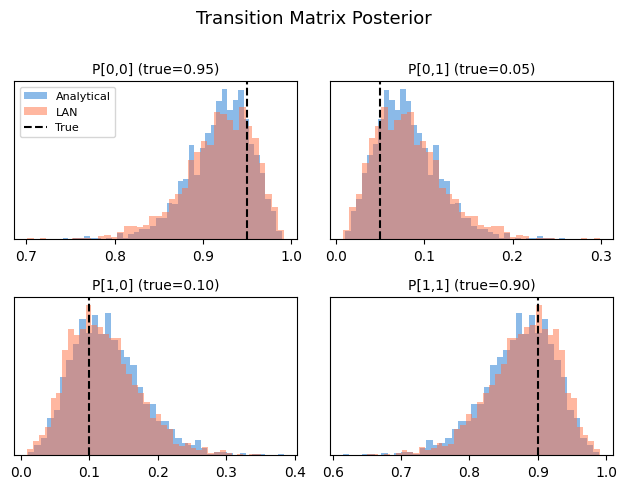

In [27]:
# --- Compare transition matrix posteriors: Analytical vs. LAN ---
# Each subplot shows one entry P[i, j] of the 2x2 transition matrix.
# The diagonal entries (P[0,0] and P[1,1]) represent regime persistence ("stickiness").

fig, axes = plt.subplots(2, 2)

for i in range(K):
    for j in range(K):
        ax = axes[i, j]
        for idata, label, color in [
            (idata_analytical, "Analytical", "#1976D2"),
            (idata_approx, "LAN", "#FF7043"),
        ]:
            samples = idata.posterior["P"].values[:, :, i, j].flatten()
            ax.hist(samples, bins=40, alpha=0.5, density=True, color=color, label=label)
        ax.axvline(TRUE_P[i, j], color="k", linestyle="--", linewidth=1.5, label="True")
        ax.set_title(f"P[{i},{j}] (true={TRUE_P[i, j]:.2f})", fontsize=10)
        ax.set_yticks([])

axes[0, 0].legend(fontsize=8)
fig.suptitle("Transition Matrix Posterior", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### RT Distributions by Regime

We compare the observed RT distributions per ground-truth regime against the posterior predictive under the analytical model's MAP parameters.

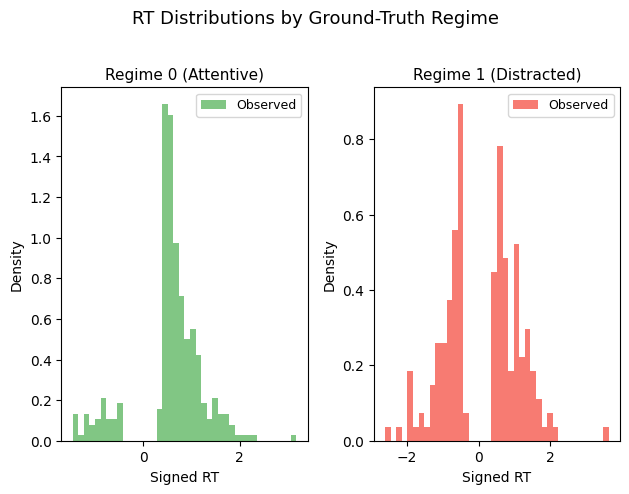

In [28]:
# --- RT distributions by ground-truth regime ---
# "Signed RT" = RT * response direction, so we can visualize both speed and
# choice in a single histogram. The attentive regime should show tighter,
# more positive RTs (higher drift -> faster, more accurate responses).

fig, axes = plt.subplots(1, 2)

for k, (label, color) in enumerate(
    [("Regime 0 (Attentive)", "#4CAF50"), ("Regime 1 (Distracted)", "#F44336")]
):
    ax = axes[k]
    mask = true_regimes == k

    signed_rt = data[mask, 0] * data[mask, 1]
    ax.hist(signed_rt, bins=40, density=True, alpha=0.7, color=color, label="Observed")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Signed RT")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

fig.suptitle("RT Distributions by Ground-Truth Regime", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## Part 8: Summary and Extensions

### What we demonstrated

- **HMM scaffold**: A generic forward-algorithm-based HMM in PyMC using `pytensor.scan` and `pm.Potential`. The discrete regime sequence is marginalized, yielding a model with only continuous parameters amenable to NUTS.
- **Plug-and-play emissions**: Two different DDM likelihoods -- analytical (Navarro & Fuss) and approximate differentiable (LAN via ONNX) -- plugged into the *same* HMM skeleton using `DDM.dist()` / `DDMApprox.dist()` + `pm.logp()`.
- **Regime recovery**: Post-hoc FFBS to infer the most likely regime sequence from posterior parameter draws.
- **NumPyro backend**: Both models were sampled with `nuts_sampler="numpyro"`, leveraging JAX compilation for speed. Note that this is de facto important. The "numpyro" sampler can be much much faster than the 

### Interpretation tips

- **Label switching**: Despite the ordering constraint `v[0] > v[1]`, check that posteriors are unimodal across chains. If you see bimodality, consider stronger priors or an informative initialization.
- **Sticky prior**: The Dirichlet concentration (`sticky_diag=20`) strongly favours self-transitions. This is a useful inductive bias for cognitive data where regime switches are rare, but adjust it for your domain.
- **Number of regimes**: We fixed $K=2$. In practice, compare models with different $K$ using LOO-CV or WAIC (note: these can be tricky for HMMs due to the dependent observations).

### Natural extensions (future tutorials, please help us :))

1. **More switching parameters**: Let $a$ (boundary separation) or $t$ (non-decision time) also switch across regimes.
2. **Hierarchical structure**: Pool regime-specific parameters across participants, e.g. $v_k^{(s)} \sim \mathcal{N}(\mu_{v_k}, \sigma_{v_k})$.
3. **Covariate-driven transitions**: Model the transition matrix as a function of trial-level covariates (e.g. difficulty, stimulus type).
4. **More complex SSMs**: Replace the DDM with any other model supported by HSSM (e.g., `ddm_sdv`, `angle`, `levy`, `race_no_bias_angle_4`), simply by swapping the emission distribution.
5. **Duration-dependent HMMs**: Extend to semi-Markov models where regime duration has an explicit distribution.

This tutorial serves as a foundation. We are considering the addition of a more fleshed out class around Hidden Markov models.